# ANALISIS DATOS : HEART FAILURE PREDICTION

## 1. CARGA DE DATOS

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# lectura de datos en Python
heart = pd.read_csv('./../heart/heart.csv')

## 2. Explorar datos (EDA)

In [9]:
heart.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [10]:
heart.shape

(918, 12)

In [11]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [12]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
pd.read_csv('./../heart/heart.csv')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [14]:
heart.min()

Age                 28
Sex                  F
ChestPainType      ASY
RestingBP            0
Cholesterol          0
FastingBS            0
RestingECG         LVH
MaxHR               60
ExerciseAngina       N
Oldpeak           -2.6
ST_Slope          Down
HeartDisease         0
dtype: object

In [15]:
heart.max()

Age                77
Sex                 M
ChestPainType      TA
RestingBP         200
Cholesterol       603
FastingBS           1
RestingECG         ST
MaxHR             202
ExerciseAngina      Y
Oldpeak           6.2
ST_Slope           Up
HeartDisease        1
dtype: object

In [16]:
df_heart = pd.DataFrame(heart, columns=['Age','Sex','ChestPainType','RestingBP','Cholesterol','FastingBS','RestingECG','MaxHR','ExerciseAngina','Oldpeak','ST_Slope'])
df_heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [17]:
# df_heart.mean()

## 3. PRE-PROCESSING

### 3.1 Fixing Problems

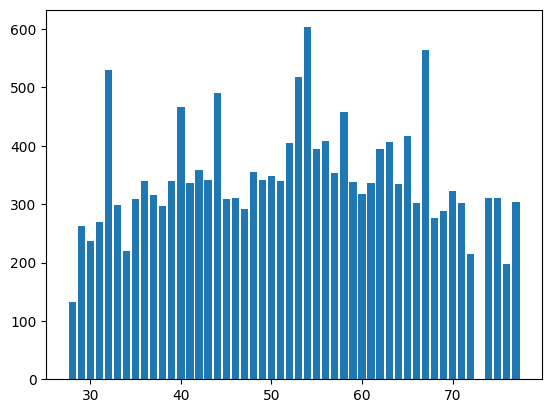

In [18]:
plt.bar(heart['Age'], heart['Cholesterol'])
plt.show()

In [19]:
heart[heart['Cholesterol']==0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [20]:
heart[heart['RestingBP']==0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [21]:
len(heart[heart['Cholesterol']==0])

172

In [22]:
len(heart[heart['RestingBP']==0])

1

In [23]:
# Calcular la media de Cholesterol excluyendo los ceros.
# Pista: filtra primero las filas donde 
# Cholesterol es distinto de 0 con != y luego aplica .mean()

In [24]:
heart[heart['Cholesterol']!=0]['Cholesterol'].mean()


np.float64(244.6353887399464)

In [25]:
heart.loc[heart['Cholesterol']==0,'Cholesterol'] = 244

In [26]:
heart[heart['RestingBP']!=0]['RestingBP'].mean()


np.float64(132.54089422028352)

In [27]:
heart.loc[heart['RestingBP']==0,'RestingBP'] = 132

In [28]:
len(heart[heart['Cholesterol']==0])

0

In [29]:
heart[heart['Cholesterol']==0].head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


### 3.2 ENCODING

In [30]:
heart['Sex'] = heart['Sex'].map({'M':1, 'F':0}).astype(int)

In [31]:
heart['ChestPainType'] = heart['ChestPainType'].map({'ATA':0, 'NAP':1, 'ASY':2, 'TA':3}).astype(int)

In [32]:
heart['RestingECG'] = heart['RestingECG'].map({'Normal':0, 'ST':1, 'LVH':2}).astype(int)

In [33]:
heart['ExerciseAngina'] = heart['ExerciseAngina'].map({'N':0, 'Y':1}).astype(int)

In [34]:
heart['ST_Slope'] = heart['ST_Slope'].map({'Flat':0, 'Up':1, 'Down':2}).astype(int)

In [35]:
heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,0,140,289,0,0,172,0,0.0,1,0
1,49,0,1,160,180,0,0,156,0,1.0,0,1
2,37,1,0,130,283,0,1,98,0,0.0,1,0
3,48,0,2,138,214,0,0,108,1,1.5,0,1
4,54,1,1,150,195,0,0,122,0,0.0,1,0


## SPLIT 70-15-15

Separarémos los datos en tres partes para que la IA pueda: 
- Con un 70% ser entrenada para comprender los tipos de datos con los que trabajará
- Con un 15% validará los tipos de datos 
- Con otro 15% comprobará/testeará con los datos restantes 

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
y = heart['HeartDisease']
x = heart.drop(columns=['HeartDisease']) 

print(x.shape)
print(y.shape)

(918, 11)
(918,)


In [56]:
# Primera llamada — separar Train (70%) del resto (30%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30)

In [47]:
print(x_train)

     Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
52    45    1              0        140          224          1           0   
85    66    1              2        140          139          0           0   
615   70    1              2        130          322          0           2   
635   67    1              2        120          229          0           2   
641   46    0              2        138          243          0           2   
..   ...  ...            ...        ...          ...        ...         ...   
317   56    1              2        140          244          1           0   
456   61    1              1        120          244          0           0   
121   52    0              1        125          272          0           0   
871   61    1              1        150          243          1           0   
742   52    0              1        136          196          0           2   

     MaxHR  ExerciseAngina  Oldpeak  ST_Slope  
52 

In [57]:
#Segunda llamada — dividir ese 30% restante en Validation y Test (15% cada uno), es decir, 50% de ese 30%:
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50)

In [40]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(642, 11)
(138, 11)
(138, 11)


## SCALING

Se hace escalar los datos para que todos los datos estén en un mismo rango, es decir aquellas columnas que trabajaen entre valores 0 a 4 estarán en un rango y las que tienen valores de 20 a 100 están en otro rango.

Por lo que habrá que escalar todos los datos a un mismo rango para que todo el trabajo sea más sencillo de entender para la IA 

In [41]:
from sklearn.preprocessing import StandardScaler

In [59]:
col = list(x_train.columns.values)
print(col)

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [58]:
col = list(x_val.columns.values)
print(col)

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [60]:
scaler = StandardScaler()

x_train[col] = scaler.fit_transform(x_train[col])

x_val[col] = scaler.transform(x_val[col])
x_test[col] = scaler.transform(x_test[col])

print(x_train.mean(axis=0).round(2))
print(x_train.std(axis=0).round(2))

Age               0.0
Sex              -0.0
ChestPainType    -0.0
RestingBP         0.0
Cholesterol      -0.0
FastingBS         0.0
RestingECG       -0.0
MaxHR             0.0
ExerciseAngina    0.0
Oldpeak           0.0
ST_Slope          0.0
dtype: float64
Age               1.0
Sex               1.0
ChestPainType     1.0
RestingBP         1.0
Cholesterol       1.0
FastingBS         1.0
RestingECG        1.0
MaxHR             1.0
ExerciseAngina    1.0
Oldpeak           1.0
ST_Slope          1.0
dtype: float64


# Guardar en varios CSV los datos de Training, Validación y Test

Para que en el pipeline cuando hagamos las fases finales no tenga que pre-procesar los datos todo el tiempo y reduce drásticamente el tiempo de espera

In [ ]:
x_train['Label']=y_train
x_train.to_csv('./xTrain.csv', index = False)

In [63]:
x_val['Label']=y_val
x_val.to_csv('./xVal.csv', index = False)

In [64]:
x_test['Label']=y_test
x_test.to_csv('./xTest.csv', index = False)

In [43]:
import tensorflow as tf
print(tf.__version__)

2.21.0
